# Detecção de Anomalias em Telemetria de Satélite
## Dataset: OPSSAT-AD — Missão OPS-SAT (ESA)

---

**Objetivo:** Classificar fragmentos de telemetria de satélite como normais ou anômalos, aplicando dois algoritmos distintos e otimizando o melhor deles com busca de hiperparâmetros.

**Pipeline:**
1. Exploração e análise do dataset
2. Pré-processamento e divisão estratificada
3. Treinamento: Random Forest vs. Gradient Boosting
4. Métricas de validação detalhadas
5. Otimização de hiperparâmetros (RandomizedSearchCV)
6. Comparação com curvas ROC-AUC

---

## 0. Imports e configurações

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

RANDOM_STATE = 42
print('✅ Imports carregados com sucesso!')

✅ Imports carregados com sucesso!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path = '/content/drive/MyDrive/Dados/balanced_augmented_dataset.csv'

In [6]:
df = pd.read_csv(path)


---
## 1. Carregamento e Exploração do Dataset

O dataset **OPSSAT-AD** contém fragmentos de telemetria de canal único coletados da missão OPS-SAT da ESA (um CubeSat laboratório). Cada linha representa um segmento curto de sinal com 18 features estatísticas calculadas manualmente.

In [7]:

print('=' * 55)
print(f'  Shape do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print('=' * 55)
print(f'  Valores nulos: {df.isnull().sum().sum()}')
print(f'  Colunas: {list(df.columns)}')
print('=' * 55)

df.head()

  Shape do dataset: 18,000 linhas × 23 colunas
  Valores nulos: 0
  Colunas: ['segment', 'train', 'sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len', 'anomaly', 'channel']


,segment,train,sampling,duration,len,mean,var,std,kurtosis,skew,...,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len,anomaly,channel
0,5,0,1,256,257,0.000011,5.279023e-10,0.000023,-1.484393,-0.060155,...,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12,0,CADC0872
1,6,1,1,252,253,0.000006,6.643180e-10,0.000026,-1.302309,-0.179240,...,66,84,6.430575e-13,7.268033e-13,252,253,2.636182e-12,2.625763e-12,0,CADC0872
2,7,0,1,379,380,0.000003,3.843725e-10,0.000020,-0.736379,-0.078294,...,111,127,3.793821e-13,6.807879e-13,379,380,1.014176e-12,1.011507e-12,0,CADC0872
3,10,1,1,316,317,0.000004,6.311006e-10,0.000025,-1.216712,-0.128176,...,97,104,5.293624e-13,8.428462e-13,316,317,1.997154e-12,1.990854e-12,0,CADC0872
4,11,1,1,229,230,-0.000005,4.332306e-10,0.000021,-1.264249,-0.232091,...,71,84,5.909420e-13,8.931565e-13,229,230,1.891837e-12,1.883611e-12,0,CADC0872


---------------------

- Estatística descritivas

In [8]:
# Estatísticas descritivas
df.describe().round(4)

,segment,train,sampling,duration,len,mean,var,std,kurtosis,skew,...,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len,anomaly
count,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,...,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000,18000.0
mean,1076.7647,0.5721,3.4469,283.3834,162.3338,0.1481,0.0412,0.1419,-0.7773,0.4354,...,1.0812,12.1746,18.9476,0.0033,0.0062,1322.8263,283.2626,0.0002,0.0008,0.5
std,559.0105,0.4948,1.9078,151.6507,170.3331,0.1737,0.0544,0.1419,1.2584,0.6329,...,0.3076,23.5790,28.6111,0.0097,0.0263,2296.5934,152.3966,0.0002,0.0011,0.5
min,1.0000,0.0000,1.0000,35.0000,8.0000,-0.0000,0.0000,0.0000,-1.8588,-1.5094,...,0.0000,0.0000,0.0000,0.0000,0.0000,104.0000,40.0000,0.0000,0.0000,0.0
25%,695.0000,0.0000,1.0000,184.0000,39.0000,0.0000,0.0000,0.0000,-1.3295,-0.0622,...,1.0000,1.0000,3.0000,0.0000,0.0000,394.0000,182.0000,0.0000,0.0000,0.0
50%,960.0000,1.0000,5.0000,235.0000,70.0000,0.1115,0.0143,0.1134,-1.0864,0.4485,...,1.0000,3.0000,7.0000,0.0002,0.0002,871.0000,240.0000,0.0001,0.0002,0.5
75%,1682.0000,1.0000,5.0000,365.0000,248.0000,0.2266,0.0629,0.2474,-0.8126,0.8270,...,1.0000,13.0000,23.0000,0.0025,0.0011,1200.0000,366.0000,0.0003,0.0012,1.0
max,2123.0000,1.0000,5.0000,1335.0000,1040.0000,1.1186,0.2725,0.5220,31.2018,4.3746,...,4.0000,240.0000,256.0000,0.0999,0.3034,20750.0000,1340.0000,0.0017,0.0080,1.0


--------------------

- Tipos de dados

In [9]:
# Tipos de dados
print('Tipos de dados:')
print(df.dtypes.to_string())

Tipos de dados:
segment               int64
train                 int64
sampling              int64
duration              int64
len                   int64
mean                float64
var                 float64
std                 float64
kurtosis            float64
skew                float64
n_peaks               int64
smooth10_n_peaks      int64
smooth20_n_peaks      int64
diff_peaks            int64
diff2_peaks           int64
diff_var            float64
diff2_var           float64
gaps_squared          int64
len_weighted          int64
var_div_duration    float64
var_div_len         float64
anomaly               int64
channel              object



---

**Dicionário de dados — OPSSAT-AD**

---

**Identificação** — colunas que não devem ser usadas como features

`segment` — Identificador único do fragmento de telemetria. É apenas um índice de linha, sem valor preditivo.

`train` — Flag do split original do dataset (1 = pertencia ao treino original). Deve ser removido para evitar data leakage.

`channel` — Nome do canal/sensor de origem do sinal (ex: CADC0872). O dataset cobre 9 canais entre magnetômetros e fotodiodos do CubeSat OPS-SAT.

---

**Características do sinal**

`sampling` — Taxa de amostragem do fragmento, variando entre 1 e 5. Mudanças na frequência de coleta são um dos desafios reais do dataset.

`duration` — Duração total do fragmento em número de amostras (comprimento temporal bruto do segmento).

`len` — Comprimento efetivo do fragmento após remoção de gaps e artefatos. Pode diferir de `duration` em sinais com lacunas.

`mean` — Média dos valores do sinal no fragmento. Captura o nível DC (componente contínua) do canal de telemetria.

`var` — Variância do sinal. Mede a dispersão dos valores em torno da média — alta variância pode indicar instabilidade ou anomalia.

`std` — Desvio padrão do sinal (raiz quadrada da variância). Está na mesma unidade do sinal original, sendo mais interpretável que a variância.

`kurtosis` — Curtose da distribuição do sinal. Mede o peso das caudas em relação a uma distribuição normal — valores altos indicam presença de picos extremos.

`skew` — Assimetria da distribuição do sinal. Valores próximos de zero indicam simetria; valores extremos sugerem comportamento irregular.

`gaps_squared` — Soma dos quadrados dos tamanhos das lacunas de dados faltantes. Captura a severidade e distribuição dos artefatos de telemetria.

`len_weighted` — Comprimento do fragmento ponderado pela taxa de amostragem (len × sampling). Normaliza a contagem de pontos pela frequência de coleta.

---

**Contagem de picos**

`n_peaks` — Número de picos detectados no sinal bruto. É a feature mais importante do modelo — picos incomuns são a principal assinatura de anomalias em sinais de telemetria.

`smooth10_n_peaks` — Picos detectados após suavização do sinal com janela de tamanho 10. Reduz ruído de alta frequência e foca em picos estruturalmente relevantes.

`smooth20_n_peaks` — Picos detectados após suavização com janela de tamanho 20 (mais agressiva). Captura apenas os picos mais pronunciados do sinal.

---

**Derivadas do sinal**

`diff_peaks` — Picos na primeira derivada discreta do sinal. Captura transições abruptas — pontos onde o sinal muda de direção rapidamente.

`diff2_peaks` — Picos na segunda derivada do sinal. Detecta mudanças na taxa de variação do sinal. Segunda feature mais importante no modelo treinado.

`diff_var` — Variância da primeira derivada. Mede quão irregular são as variações ponto a ponto — sinais anômalos tendem a ter variações mais caóticas.

`diff2_var` — Variância da segunda derivada. Captura a irregularidade das acelerações do sinal. Terceira feature mais importante no modelo treinado.

---

**Features normalizadas**

`var_div_duration` — Variância dividida pela duração do fragmento. Comportamento quase binário: vale 0 em operação normal e assume valores positivos em anomalias.

`var_div_len` — Variância dividida pelo comprimento efetivo. Normaliza a dispersão do sinal pelo número real de amostras válidas, excluindo gaps.

---

**Variável alvo**

`anomaly` — Variável alvo da classificação. 0 = operação normal, 1 = evento anômalo. O dataset é perfeitamente balanceado com 9.000 amostras de cada classe.

### Variável alvo: `anomaly`

- **0** → Operação normal
- **1** → Evento anômalo

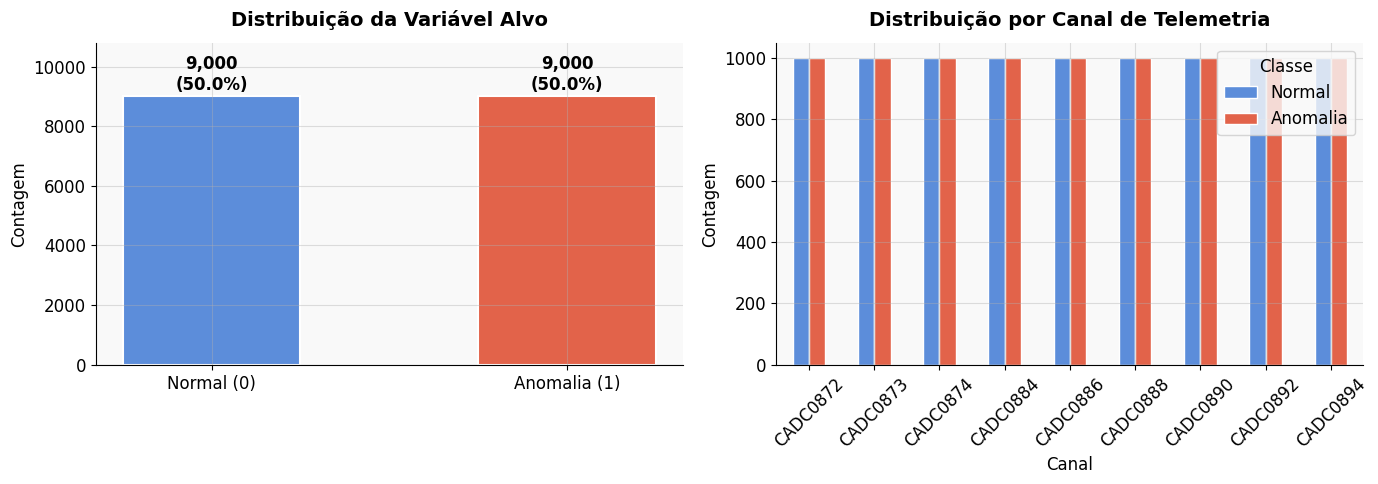


📊 Dataset perfeitamente balanceado: 9,000 normais | 9,000 anomalias


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição da variável alvo
target_counts = df['anomaly'].value_counts()
colors = ['#5C8DDA', '#E2634A']
bars = axes[0].bar(
    ['Normal (0)', 'Anomalia (1)'],
    target_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Distribuição da Variável Alvo', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Contagem')
axes[0].set_ylim(0, target_counts.max() * 1.2)
axes[0].set_facecolor('#f9f9f9')

# Distribuição por canal
channel_anomaly = df.groupby(['channel', 'anomaly']).size().unstack(fill_value=0)
channel_anomaly.columns = ['Normal', 'Anomalia']
channel_anomaly.plot(
    kind='bar',
    ax=axes[1],
    color=['#5C8DDA', '#E2634A'],
    edgecolor='white',
    linewidth=1
)
axes[1].set_title('Distribuição por Canal de Telemetria', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Classe')
axes[1].set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('fig_distribuicao_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Dataset perfeitamente balanceado: {target_counts[0]:,} normais | {target_counts[1]:,} anomalias')

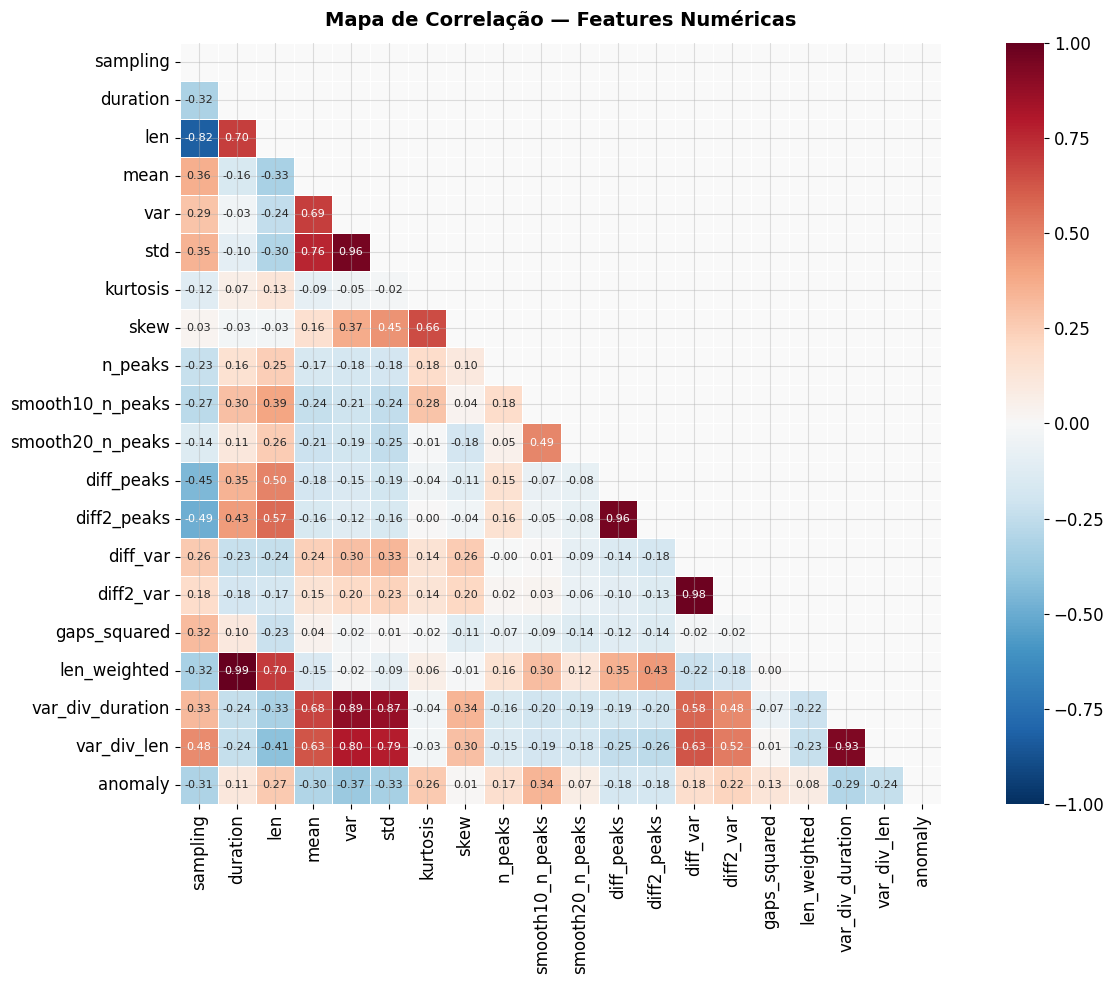

In [11]:
# Correlação entre features numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['segment', 'train', 'anomaly']]

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[numeric_cols + ['anomaly']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Mapa de Correlação — Features Numéricas', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Remoção de Colunas Redundantes - Altamente Correlacionadas

df_explicativas = df[numeric_cols].copy()
metodo = 'pearson'
df_features_com_redundancia = df_explicativas.copy()
corr_matrix = df_features_com_redundancia.corr(method=metodo).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

lista_pares = []
for col in upper.columns:
    correlacionadas = upper.index[upper[col] > 0.8].tolist()
    for row in correlacionadas:
        lista_pares.append({
            'Variavel_1': row,
            'Variavel_2': col,
            'Correlacao': upper.loc[row, col]
        })

df_redundancia = pd.DataFrame(lista_pares).sort_values(by='Correlacao', ascending=False)

print(f"{'='*60}")
print(f"ANÁLISE DE REDUNDÂNCIA (Método: {metodo.upper()})")
print(f"{'='*60}")

if not df_redundancia.empty:
    print("Pares com alta correlação encontrados (Ordenados do maior para o menor):")
    print(df_redundancia.to_string(index=False, formatters={'Correlacao': '{:,.4f}'.format}))
else:
    print("Nenhuma correlação acima de 0.8 encontrada.")

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df_explicativas = df_explicativas.drop(columns=to_drop)
df = df.drop(columns=to_drop)

print(f"\n{'='*60}")
print("RESULTADO DA REDUÇÃO")
print(f"{'='*60}")
print(f"Variáveis originais: {len(df_features_com_redundancia.columns)}")
print(f"Variáveis removidas: {len(to_drop)}")
print(f"Variáveis finais:    {len(df_explicativas.columns)}")
print(f"Variaveis que foram removidas: {', '.join(to_drop)}")
print(f"{'='*60}")

ANÁLISE DE REDUNDÂNCIA (Método: PEARSON)
Pares com alta correlação encontrados (Ordenados do maior para o menor):
      Variavel_1       Variavel_2 Correlacao
        duration     len_weighted     0.9940
        diff_var        diff2_var     0.9798
             var              std     0.9574
      diff_peaks      diff2_peaks     0.9561
var_div_duration      var_div_len     0.9308
             var var_div_duration     0.8871
             std var_div_duration     0.8686
        sampling              len     0.8247
             var      var_div_len     0.8016

RESULTADO DA REDUÇÃO
Variáveis originais: 19
Variáveis removidas: 7
Variáveis finais:    12
Variaveis que foram removidas: len, std, diff2_peaks, diff2_var, len_weighted, var_div_duration, var_div_len


In [13]:
df.columns

Index(['segment', 'train', 'sampling', 'duration', 'mean', 'var', 'kurtosis',
       'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks',
       'diff_var', 'gaps_squared', 'anomaly', 'channel'],
      dtype='object')

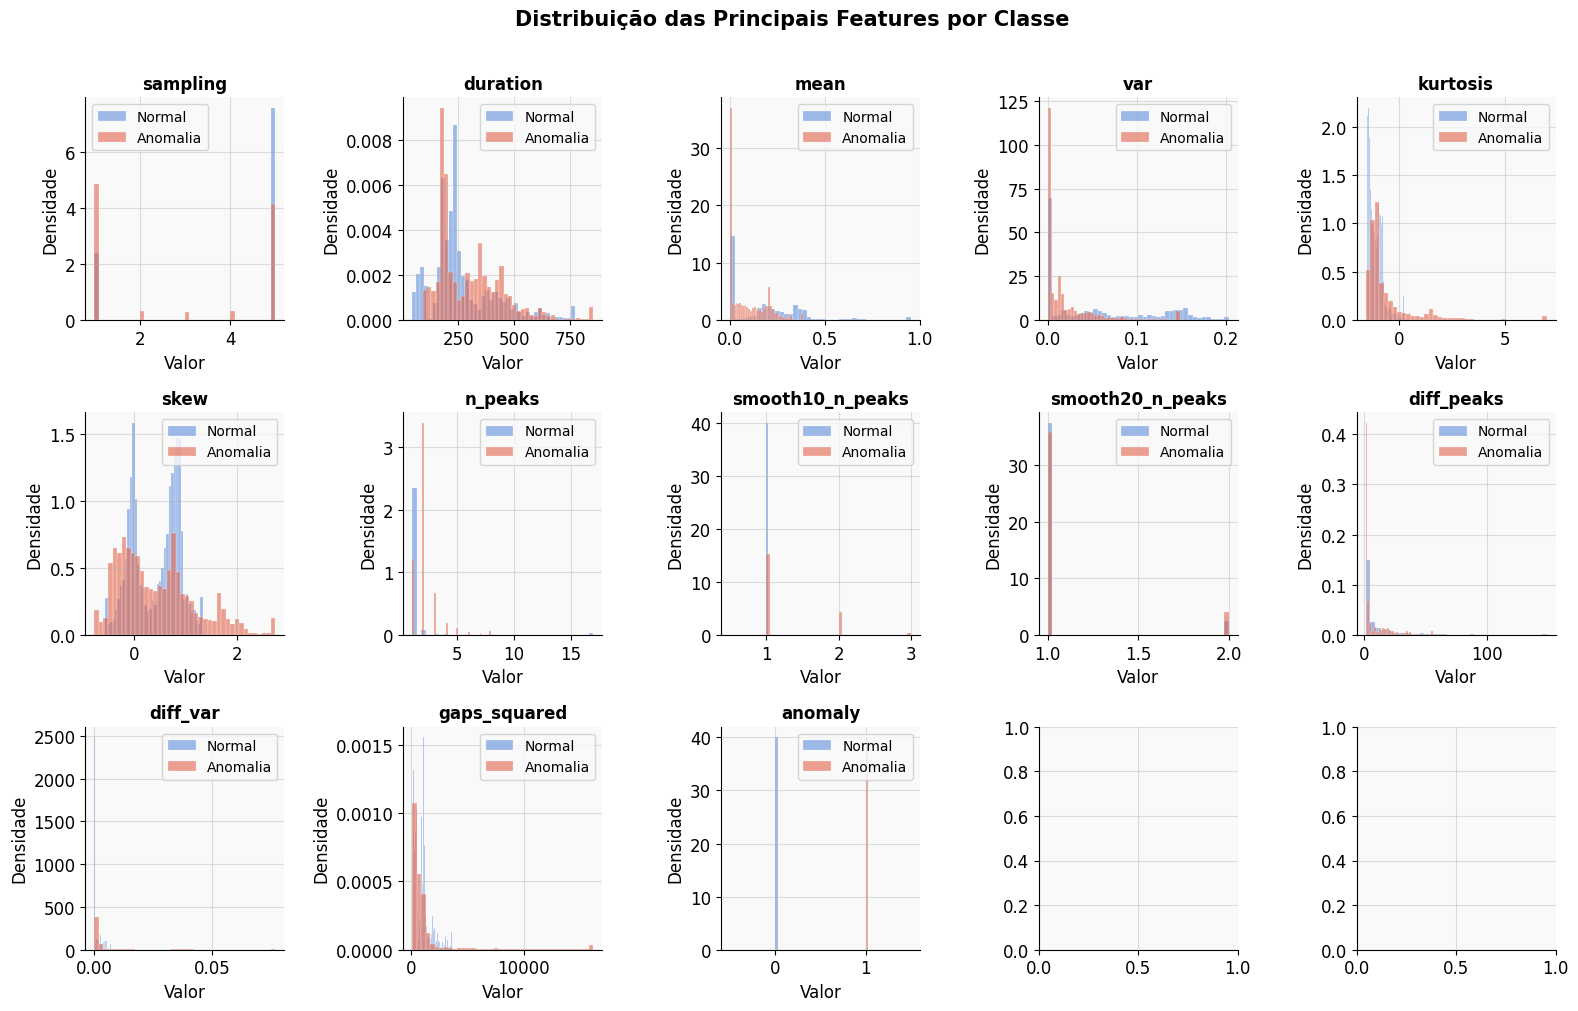

In [16]:
# Distribuição das principais features por classe
top_features = ['sampling', 'duration', 'mean', 'var', 'kurtosis',
       'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks',
       'diff_var', 'gaps_squared', 'anomaly', ]

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color, alpha in [(0, '#5C8DDA', 0.6), (1, '#E2634A', 0.6)]:
        data = df[df['anomaly'] == label][feat]
        # Clip para visualização (percentis 1-99)
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data_clipped = data.clip(p1, p99)
        axes[i].hist(
            data_clipped,
            bins=40,
            color=color,
            alpha=alpha,
            label='Normal' if label == 0 else 'Anomalia',
            density=True,
            edgecolor='white',
            linewidth=0.3
        )
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidade')
    axes[i].legend(fontsize=10)
    axes[i].set_facecolor('#f9f9f9')

fig.suptitle('Distribuição das Principais Features por Classe', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Pré-processamento e Divisão Estratificada

In [22]:
# Remover colunas não preditivas
# - 'segment': identificador único (não contém informação preditiva)
# - 'train': flag de split do dataset original (leakage se mantida)
drop_cols = ['train', 'channel']

# Codificar a coluna categórica 'channel'
le = LabelEncoder()
df['channel_enc'] = le.fit_transform(df['channel'])
print('Mapeamento de canais:')
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {orig} → {enc}')

#

# Definir features e target
feature_cols = [c for c in df.columns if c not in drop_cols + ['anomaly']]
X = df[feature_cols]
y = df['anomaly']

print(f'\nFeatures selecionadas ({len(feature_cols)}):')
print(feature_cols)

Mapeamento de canais:
  CADC0872 → 0
  CADC0873 → 1
  CADC0874 → 2
  CADC0884 → 3
  CADC0886 → 4
  CADC0888 → 5
  CADC0890 → 6
  CADC0892 → 7
  CADC0894 → 8

Features selecionadas (20):
['sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len', 'channel_enc']


In [17]:
# Definir o identificador único como índice (mantém a rastreabilidade)
df = df.set_index('segment')

# Codificar a coluna categórica 'channel'
le = LabelEncoder()
df['channel_enc'] = le.fit_transform(df['channel'])

print('Mapeamento de canais:')
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {orig} → {enc}')

# Remover colunas que não devem ir para o modelo
# Removemos 'channel' (porque criamos a 'channel_enc') e 'train' (leakage)
drop_cols = ['train', 'channel']

# Definir features e target
feature_cols = [c for c in df.columns if c not in drop_cols + ['anomaly']]
X = df[feature_cols]
y = df['anomaly']

print(f'\nFeatures selecionadas ({len(feature_cols)}):')
print(feature_cols)

Mapeamento de canais:
  CADC0872 → 0
  CADC0873 → 1
  CADC0874 → 2
  CADC0884 → 3
  CADC0886 → 4
  CADC0888 → 5
  CADC0890 → 6
  CADC0892 → 7
  CADC0894 → 8

Features selecionadas (13):
['sampling', 'duration', 'mean', 'var', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff_var', 'gaps_squared', 'channel_enc']


In [18]:
# Divisão treino/teste estratificada (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # garante proporção igual em treino e teste
)

print('=' * 50)
print('  Divisão dos dados')
print('=' * 50)
print(f'  Treino : {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Teste  : {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Features: {X_train.shape[1]}')
print('=' * 50)
print(f'\nProporção de anomalias no treino : {y_train.mean():.2%}')
print(f'Proporção de anomalias no teste  : {y_test.mean():.2%}')
print('\n✅ Estratificação manteve o balanceamento em ambos os splits.')

  Divisão dos dados
  Treino : 14,400 amostras (80%)
  Teste  : 3,600 amostras (20%)
  Features: 13

Proporção de anomalias no treino : 50.00%
Proporção de anomalias no teste  : 50.00%

✅ Estratificação manteve o balanceamento em ambos os splits.


---
## 3. Treinamento dos Modelos de Classificação

Serão treinados dois algoritmos distintos baseados em árvores de decisão:

| Algoritmo | Estratégia | Característica principal |
|---|---|---|
| **Random Forest** | Bagging (paralelo) | Combinação de árvores independentes por votação |
| **Gradient Boosting** | Boosting (sequencial) | Correção iterativa dos erros do modelo anterior |

In [19]:
# Função auxiliar para avaliar qualquer modelo
def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    """
    Treina e avalia um classificador, retornando métricas e curva ROC.
    """
    # Treinamento
    modelo.fit(X_train, y_train)

    # Predições
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    metricas = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
    }
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Exibição
    print(f'\n{"-"*55}')
    print(f'  MODELO: {nome}')
    print(f'{"-"*55}')
    for k, v in metricas.items():
        bar = '█' * int(v * 30)
        print(f'  {k:<12} {v:.4f}  {bar}')
    print(f'\n  Relatório completo:')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalia']))

    return modelo, y_pred, y_prob, fpr, tpr, metricas

### 3.1 Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1  # usa todos os núcleos disponíveis
)

rf_model, rf_pred, rf_prob, rf_fpr, rf_tpr, rf_metricas = avaliar_modelo(
    'Random Forest', rf, X_train, X_test, y_train, y_test
)


-------------------------------------------------------
  MODELO: Random Forest
-------------------------------------------------------
  accuracy     0.9928  █████████████████████████████
  precision    0.9895  █████████████████████████████
  recall       0.9961  █████████████████████████████
  f1           0.9928  █████████████████████████████
  roc_auc      0.9994  █████████████████████████████

  Relatório completo:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1800
    Anomalia       0.99      1.00      0.99      1800

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600



### 3.2 Gradient Boosting

In [21]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model, gb_pred, gb_prob, gb_fpr, gb_tpr, gb_metricas = avaliar_modelo(
    'Gradient Boosting', gb, X_train, X_test, y_train, y_test
)


-------------------------------------------------------
  MODELO: Gradient Boosting
-------------------------------------------------------
  accuracy     0.9703  █████████████████████████████
  precision    0.9732  █████████████████████████████
  recall       0.9672  █████████████████████████████
  f1           0.9702  █████████████████████████████
  roc_auc      0.9962  █████████████████████████████

  Relatório completo:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1800
    Anomalia       0.97      0.97      0.97      1800

    accuracy                           0.97      3600
   macro avg       0.97      0.97      0.97      3600
weighted avg       0.97      0.97      0.97      3600



---
## 4. Métricas de Validação e Visualizações

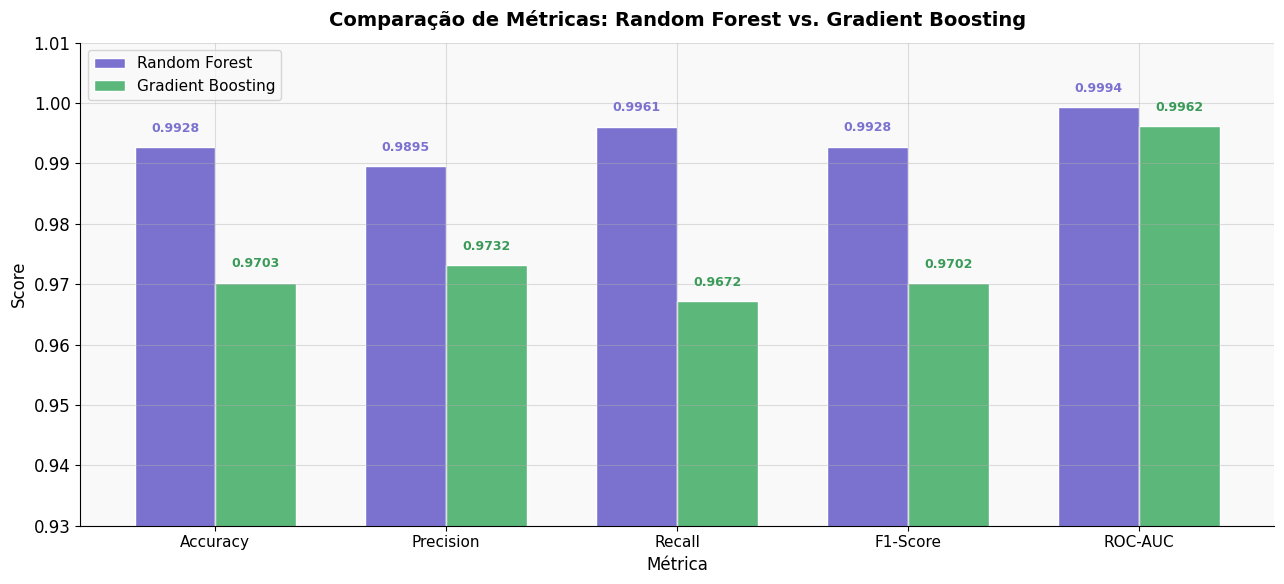

In [22]:
# Comparação das métricas entre os dois modelos
metricas_nomes = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

rf_vals = [rf_metricas[m] for m in metricas_nomes]
gb_vals = [gb_metricas[m] for m in metricas_nomes]

x = np.arange(len(metricas_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest',
               color='#7B72D0', edgecolor='white', linewidth=1)
bars2 = ax.bar(x + width/2, gb_vals, width, label='Gradient Boosting',
               color='#5CB87A', edgecolor='white', linewidth=1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='#7B72D0', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, color='#3a9a58', fontweight='bold')

ax.set_xlabel('Métrica', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Métricas: Random Forest vs. Gradient Boosting', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=11)
ax.set_ylim(0.93, 1.01)
ax.legend(fontsize=11)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('fig_comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

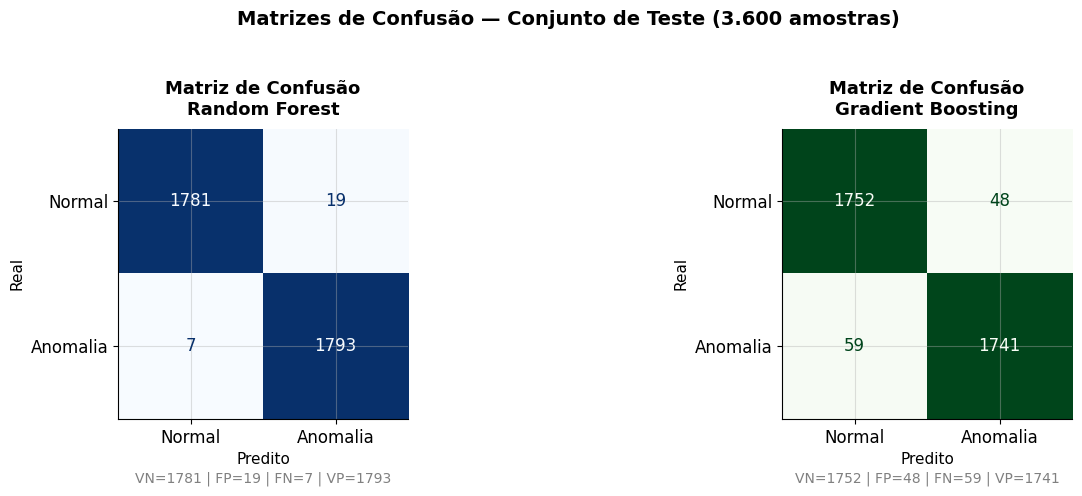

In [23]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, titulo, cor in [
    (axes[0], rf_pred, 'Random Forest', 'Blues'),
    (axes[1], gb_pred, 'Gradient Boosting', 'Greens')
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomalia'])
    disp.plot(ax=ax, cmap=cor, colorbar=False, values_format='d')
    ax.set_title(f'Matriz de Confusão\n{titulo}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predito', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

    # Anotações adicionais
    vn, fp = cm[0, 0], cm[0, 1]
    fn, vp = cm[1, 0], cm[1, 1]
    ax.text(0.5, -0.22,
            f'VN={vn} | FP={fp} | FN={fn} | VP={vp}',
            ha='center', transform=ax.transAxes,
            fontsize=10, color='gray')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste (3.600 amostras)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Tabela resumo de métricas
resumo = pd.DataFrame({
    'Métrica': metricas_labels,
    'Random Forest': [f'{v:.4f}' for v in rf_vals],
    'Gradient Boosting': [f'{v:.4f}' for v in gb_vals],
    'Vencedor': ['RF' if r > g else 'GB'
                 for r, g in zip(rf_vals, gb_vals)]
})
print('\n📋 Resumo Comparativo:')
print(resumo.to_string(index=False))
print('\n🏆 Random Forest vence em todas as métricas → selecionado para otimização!')


📋 Resumo Comparativo:
  Métrica Random Forest Gradient Boosting Vencedor
 Accuracy        0.9928            0.9703       RF
Precision        0.9895            0.9732       RF
   Recall        0.9961            0.9672       RF
 F1-Score        0.9928            0.9702       RF
  ROC-AUC        0.9994            0.9962       RF

🏆 Random Forest vence em todas as métricas → selecionado para otimização!


---
## 5. Otimização de Hiperparâmetros — RandomizedSearchCV

O **Random Forest** foi selecionado por seu desempenho superior. Aplicamos o `RandomizedSearchCV` com validação cruzada estratificada de 5 folds, otimizando o score ROC-AUC.

### Espaço de busca (4 hiperparâmetros):

| Hiperparâmetro | Valores | O que controla |
|---|---|---|
| `n_estimators` | [50, 100, 200, 300, 500] | Número de árvores na floresta |
| `max_depth` | [None, 10, 20, 30] | Profundidade máxima de cada árvore |
| `min_samples_split` | [2, 5, 10] | Mínimo de amostras para dividir um nó |
| `max_features` | ['sqrt', 'log2', 0.5] | Features consideradas em cada split |

In [25]:
# Espaço de busca de hiperparâmetros
param_dist = {
    'n_estimators'     : [50, 100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2', 0.5],
}

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV — testa 20 combinações aleatórias
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,             # número de combinações testadas
    cv=cv,
    scoring='roc_auc',    # métrica de otimização
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('🔎 Iniciando busca de hiperparâmetros...')
print(f'   Combinações testadas: 20 de {5*4*3*3} possíveis')
print(f'   Folds por combinação: 5')
print(f'   Total de fits: 100\n')

search.fit(X_train, y_train)

print(f'\n✅ Busca concluída!')
print(f'   Melhor score CV (ROC-AUC): {search.best_score_:.6f}')
print(f'   Melhores hiperparâmetros:')
for k, v in search.best_params_.items():
    print(f'     {k}: {v}')

🔎 Iniciando busca de hiperparâmetros...
   Combinações testadas: 20 de 180 possíveis
   Folds por combinação: 5
   Total de fits: 100

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Busca concluída!
   Melhor score CV (ROC-AUC): 0.999821
   Melhores hiperparâmetros:
     n_estimators: 300
     min_samples_split: 2
     max_features: log2
     max_depth: 30


In [26]:
# Resultados da busca — top 10 combinações
cv_results = pd.DataFrame(search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)

print('📊 Top 10 combinações testadas:')
cols_exibir = ['param_n_estimators', 'param_max_depth',
               'param_min_samples_split', 'param_max_features',
               'mean_test_score', 'std_test_score']
top10 = cv_results_sorted[cols_exibir].head(10).copy()
top10.columns = ['n_estimators', 'max_depth', 'min_samples_split',
                 'max_features', 'AUC (média)', 'AUC (std)']
top10['AUC (média)'] = top10['AUC (média)'].map('{:.6f}'.format)
top10['AUC (std)'] = top10['AUC (std)'].map('{:.6f}'.format)
top10 = top10.reset_index(drop=True)
top10.index += 1
print(top10.to_string())

📊 Top 10 combinações testadas:
    n_estimators max_depth  min_samples_split max_features AUC (média) AUC (std)
1            300        30                  2         log2    0.999821  0.000058
2            500      None                  2         log2    0.999819  0.000052
3            300        20                  2         sqrt    0.999816  0.000062
4            100      None                  2         log2    0.999798  0.000058
5            500      None                  5         log2    0.999787  0.000065
6            500        30                  5         log2    0.999787  0.000065
7            300        20                  5         log2    0.999784  0.000070
8            200        30                  5         sqrt    0.999782  0.000065
9            100        20                  5         sqrt    0.999776  0.000061
10            50      None                  2         log2    0.999774  0.000071


In [27]:
# Avaliação do modelo otimizado
best_model = search.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_prob = best_model.predict_proba(X_test)[:, 1]
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_prob)

tuned_metricas = {
    'accuracy' : accuracy_score(y_test, tuned_pred),
    'precision': precision_score(y_test, tuned_pred),
    'recall'   : recall_score(y_test, tuned_pred),
    'f1'       : f1_score(y_test, tuned_pred),
    'roc_auc'  : roc_auc_score(y_test, tuned_prob),
}

print('=' * 58)
print('  MODELO OTIMIZADO — Random Forest + Tuning')
print('=' * 58)
for k, v in tuned_metricas.items():
    delta = v - rf_metricas[k]
    sinal = '+' if delta >= 0 else ''
    print(f'  {k:<12} {v:.6f}   (delta: {sinal}{delta:+.6f})')
print('\n  Relatório completo:')
print(classification_report(y_test, tuned_pred, target_names=['Normal', 'Anomalia']))

  MODELO OTIMIZADO — Random Forest + Tuning
  accuracy     0.992778   (delta: ++0.000000)
  precision    0.989514   (delta: ++0.000000)
  recall       0.996111   (delta: ++0.000000)
  f1           0.992802   (delta: ++0.000000)
  roc_auc      0.999671   (delta: ++0.000317)

  Relatório completo:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1800
    Anomalia       0.99      1.00      0.99      1800

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600



---
## 6. Comparação com Curvas ROC-AUC

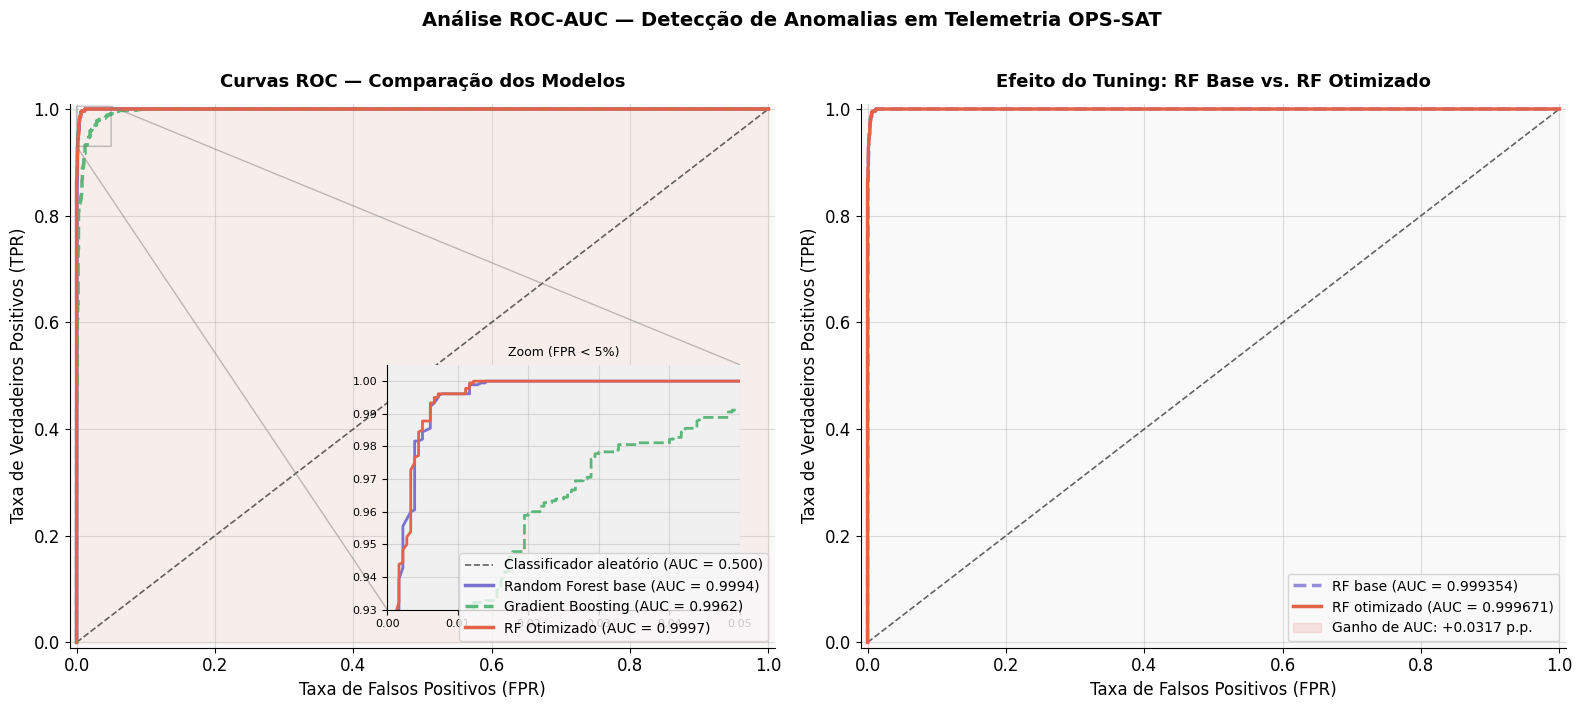

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# === GRÁFICO 1: Curvas ROC — Todos os modelos ===
ax = axes[0]

# Linha de referência (classificador aleatório)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Classificador aleatório (AUC = 0.500)')

# Random Forest base
ax.plot(rf_fpr, rf_tpr,
        color='#7B72D0', linewidth=2.5,
        label=f'Random Forest base (AUC = {rf_metricas["roc_auc"]:.4f})')

# Gradient Boosting
ax.plot(gb_fpr, gb_tpr,
        color='#5CB87A', linewidth=2.5, linestyle='--',
        label=f'Gradient Boosting (AUC = {gb_metricas["roc_auc"]:.4f})')

# RF Otimizado
ax.plot(tuned_fpr, tuned_tpr,
        color='#E2634A', linewidth=2.5,
        label=f'RF Otimizado (AUC = {tuned_metricas["roc_auc"]:.4f})')

# Sombreamento da área da curva RF Otimizado
ax.fill_between(tuned_fpr, tuned_tpr, alpha=0.07, color='#E2634A')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_facecolor('#f9f9f9')

# Zoom na região de alto desempenho
axins = ax.inset_axes([0.45, 0.07, 0.5, 0.45])
axins.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axins.plot(rf_fpr, rf_tpr, color='#7B72D0', linewidth=2)
axins.plot(gb_fpr, gb_tpr, color='#5CB87A', linewidth=2, linestyle='--')
axins.plot(tuned_fpr, tuned_tpr, color='#E2634A', linewidth=2)
axins.set_xlim(0, 0.05)
axins.set_ylim(0.93, 1.005)
axins.set_facecolor('#f0f0f0')
axins.set_title('Zoom (FPR < 5%)', fontsize=9)
axins.tick_params(labelsize=8)
ax.indicate_inset_zoom(axins, edgecolor='gray', alpha=0.5)


# === GRÁFICO 2: RF base vs. RF Otimizado ===
ax2 = axes[1]

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6)
ax2.plot(rf_fpr, rf_tpr,
         color='#7B72D0', linewidth=2.5, linestyle='--',
         label=f'RF base (AUC = {rf_metricas["roc_auc"]:.6f})',
         alpha=0.8)
ax2.plot(tuned_fpr, tuned_tpr,
         color='#E2634A', linewidth=2.5,
         label=f'RF otimizado (AUC = {tuned_metricas["roc_auc"]:.6f})')
rf_tpr_interp = np.interp(tuned_fpr, rf_fpr, rf_tpr)

ax2.fill_between(tuned_fpr, tuned_tpr, rf_tpr_interp,
                 alpha=0.15, color='#E2634A',
                 label=f'Ganho de AUC: +{(tuned_metricas["roc_auc"]-rf_metricas["roc_auc"])*100:.4f} p.p.')

ax2.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax2.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax2.set_title('Efeito do Tuning: RF Base vs. RF Otimizado', fontsize=13, fontweight='bold', pad=12)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.01])
ax2.set_facecolor('#f9f9f9')

ax2.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax2.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax2.set_title('Efeito do Tuning: RF Base vs. RF Otimizado', fontsize=13, fontweight='bold', pad=12)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.01])
ax2.set_facecolor('#f9f9f9')

plt.suptitle('Análise ROC-AUC — Detecção de Anomalias em Telemetria OPS-SAT',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

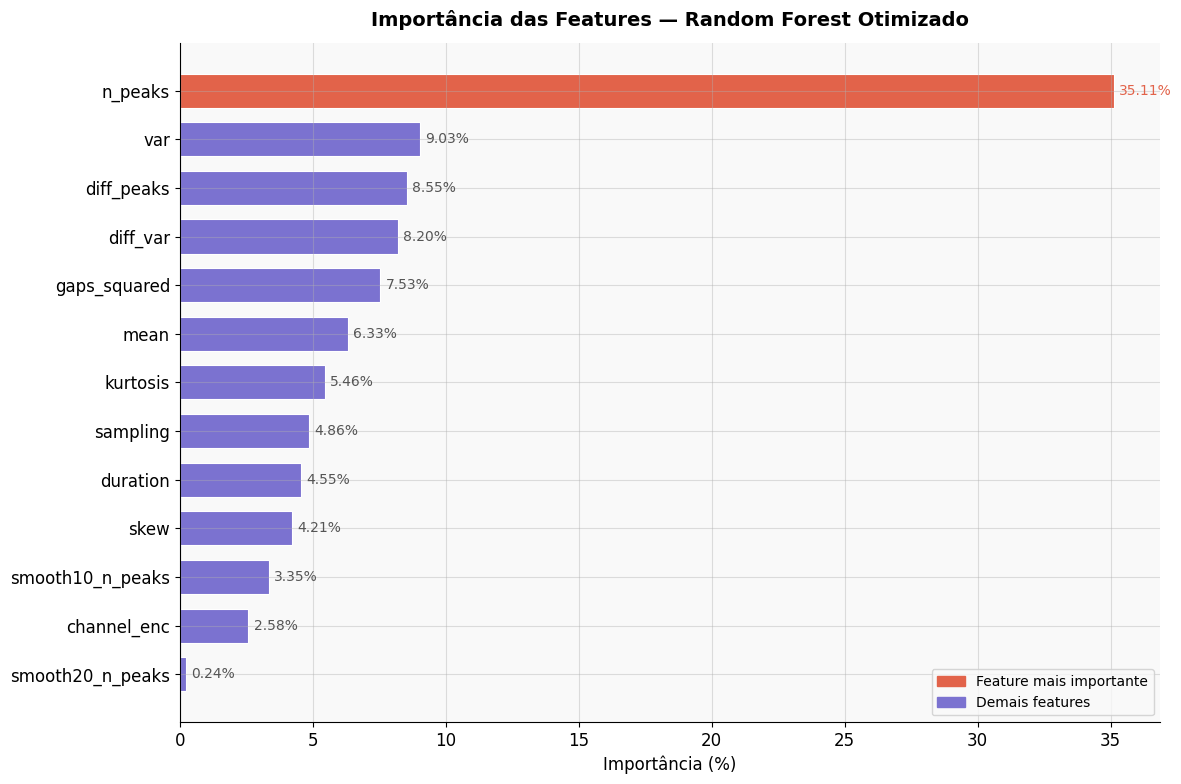


📌 Top 5 features mais importantes:
  n_peaks                35.11%
  var                    9.03%
  diff_peaks             8.55%
  diff_var               8.20%
  gaps_squared           7.53%


In [31]:
# Importância das features — RF Otimizado
fi = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

cores = ['#E2634A' if fi.index[-1] == f else '#7B72D0' for f in fi.index]
bars = ax.barh(fi.index, fi.values * 100,
               color=cores, edgecolor='white', linewidth=0.8, height=0.7)

for bar, val in zip(bars, fi.values * 100):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10,
            color='#E2634A' if val == fi.values.max()*100 else '#555')

ax.set_xlabel('Importância (%)', fontsize=12)
ax.set_title('Importância das Features — Random Forest Otimizado', fontsize=14, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f9')

destaque = mpatches.Patch(color='#E2634A', label='Feature mais importante')
demais   = mpatches.Patch(color='#7B72D0', label='Demais features')
ax.legend(handles=[destaque, demais], fontsize=10)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Top 5 features mais importantes:')
for feat, imp in fi.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<22} {imp*100:.2f}%')

---
## 7. Resumo Final

In [32]:
print('=' * 65)
print('  RESUMO FINAL — Detecção de Anomalias OPS-SAT')
print('=' * 65)

print('\n📂 Dataset')
print(f'  Amostras totais  : 18.000 (9.000 normais | 9.000 anomalias)')
print(f'  Features usadas  : {len(feature_cols)}')
print(f'  Divisão          : 80% treino | 20% teste (estratificado)')

print('\n🤖 Modelos treinados')
linhas = [
    ('Métrica',         'RF base',    'Grad. Boost.',  'RF otimizado'),
    ('-' * 16,          '-' * 12,     '-' * 12,        '-' * 12),
    ('Accuracy',        f"{rf_metricas['accuracy']:.4f}",  f"{gb_metricas['accuracy']:.4f}",  f"{tuned_metricas['accuracy']:.4f}"),
    ('Precision',       f"{rf_metricas['precision']:.4f}", f"{gb_metricas['precision']:.4f}", f"{tuned_metricas['precision']:.4f}"),
    ('Recall',          f"{rf_metricas['recall']:.4f}",    f"{gb_metricas['recall']:.4f}",    f"{tuned_metricas['recall']:.4f}"),
    ('F1-Score',        f"{rf_metricas['f1']:.4f}",        f"{gb_metricas['f1']:.4f}",        f"{tuned_metricas['f1']:.4f}"),
    ('ROC-AUC',         f"{rf_metricas['roc_auc']:.4f}",   f"{gb_metricas['roc_auc']:.4f}",   f"{tuned_metricas['roc_auc']:.4f}"),
]
for row in linhas:
    print(f'  {row[0]:<16} {row[1]:<13} {row[2]:<13} {row[3]}')

print('\n🔧 Tuning (RandomizedSearchCV)')
for k, v in search.best_params_.items():
    print(f'  {k:<20}: {v}')

ganho_auc = (tuned_metricas['roc_auc'] - rf_metricas['roc_auc']) * 100
print(f'\n✅ Ganho de AUC com tuning: {ganho_auc:+.4f} p.p.')
print(f'\n🏆 Modelo final recomendado: Random Forest Otimizado')
print(f'   ROC-AUC = {tuned_metricas["roc_auc"]:.6f} | Accuracy = {tuned_metricas["accuracy"]:.4f}')
print('=' * 65)

  RESUMO FINAL — Detecção de Anomalias OPS-SAT

📂 Dataset
  Amostras totais  : 18.000 (9.000 normais | 9.000 anomalias)
  Features usadas  : 13
  Divisão          : 80% treino | 20% teste (estratificado)

🤖 Modelos treinados
  Métrica          RF base       Grad. Boost.  RF otimizado
  ---------------- ------------  ------------  ------------
  Accuracy         0.9928        0.9703        0.9928
  Precision        0.9895        0.9732        0.9895
  Recall           0.9961        0.9672        0.9961
  F1-Score         0.9928        0.9702        0.9928
  ROC-AUC          0.9994        0.9962        0.9997

🔧 Tuning (RandomizedSearchCV)
  n_estimators        : 300
  min_samples_split   : 2
  max_features        : log2
  max_depth           : 30

✅ Ganho de AUC com tuning: +0.0317 p.p.

🏆 Modelo final recomendado: Random Forest Otimizado
   ROC-AUC = 0.999671 | Accuracy = 0.9928


Extração do artefato do modelo

In [33]:
import joblib

# 1. Salvar o modelo treinado em um arquivo
joblib.dump(rf_model, 'modelo_random_forest.pkl')
print("Modelo salvo com sucesso!")

# --- Em outro script ou momento posterior ---

# 2. Carregar o modelo de volta para a memória
modelo_carregado = joblib.load('modelo_random_forest.pkl')

# 3. Usar o modelo carregado para fazer novas previsões
# novas_previsoes = modelo_carregado.predict(novos_dados)

Modelo salvo com sucesso!
